# Multiple particles falling in the F-layer

This notebook outlines how we can use our model of a single falling and growing iron particle 
together with out nucleation model to to look at what happens once particles are permitted
to nuclate everywhere. The notebook roughly mirrors the layer_models.py python script, which
is used to run each of our model cases, but does not generate any of the figures for the
manuscript. 

The bulk of the code for this notebook lives in python modules (`layer_setup.py`
and `flayer.py`). These modules make use of almost all of our other modules either
directly or indirectly. NB: the division by zero errors are due to the LLVM compiler
used by numba and do not impact the results (the ieee error flag gets set but errors
do not make it back into the arrays).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
%matplotlib inline

import particle_evolution
import feo_thermodynamics as feot
import earth_model
import flayer
import layer_setup

/Users/andreww/Code/slurry/layer_diffusion.py:145: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  fig_axs[1].set_ylabel('$\mathrm{d}c / \mathrm{d}R$ (?)')
/Users/andreww/Code/slurry/layer_diffusion.py:149: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  fig_axs[1].set_ylabel('$\mathrm{d}T / \mathrm{d}R$ (K/m)')


## Setup an F-layer configuration

We need a reasonable description of the F-layer. We do this by defining a radius for the ICB 
and a radius for the top of the F-layer, assume that pressure (and gravity) are given by PREM,
and define functions for temperature and composition. (The following function generates the functions
we'll need). 

The (total) composition is assumed to be constant in the core above the F-layer, and may vary as a quadratic 
function of radius within the F-layer. This is set up by providing two compositions, one
at the top and one at the bottom of the F-layer. These are provided as mole fraction Fe
and are needed to set up the temperature.

For temperature we extrapolate down an adiabat until we reach the top of the F-layer and then
assume a linear variation in temperature with radius. The adiabatic temperature is given by:

$$ T_a(r) = T_{CMB} \left(\frac{\rho(r)}{\rho_{CMB}}\right)^{\gamma} $$

where $\gamma$ is the Grunissen parameter for the core (e.g. 1.5) and $T_{CMB}$ is the 
temperature at the CMB. We assume PREM for the density, and find $T_{CMB}$ such
that $T_a(r)$ is equal to the liquidus (at our chosen composition) at the top of the F-layer.
This is done by root finding. 
We choose the temperature at the ICB by further extrapolating down the adiabat and applying 
a small change (or order 10 K) such that the F-layer can be sub- (or super-) adiabatic fitting
a second order polynomial with zero gradient at the ICB. 

Note that allowing the temperature and composition to vary with radius could allow the
F-layer to depart from the two phase region (either by dipping below the solidus/eutectic
temperature or by exceeding the pressure-dependent liquidus). We don't check for this in the
notebook, but do exclude such cases from the analysis in the manuscript.

Pressure at ICB: 329.1010089948369 GPa
Pressure at top of F-layer 317.7026904318656 GPa
g at ICB: 4.403124222842614 m/s**2
g at top of F-layer 5.010242771751181 m/s**2
Temberature at top of F-layer is 5495.375594101562 K
Temberature at ICB is 5580.445773134323 K
Brunt Vaisala frequency is 0.00017105475434204596 Hz


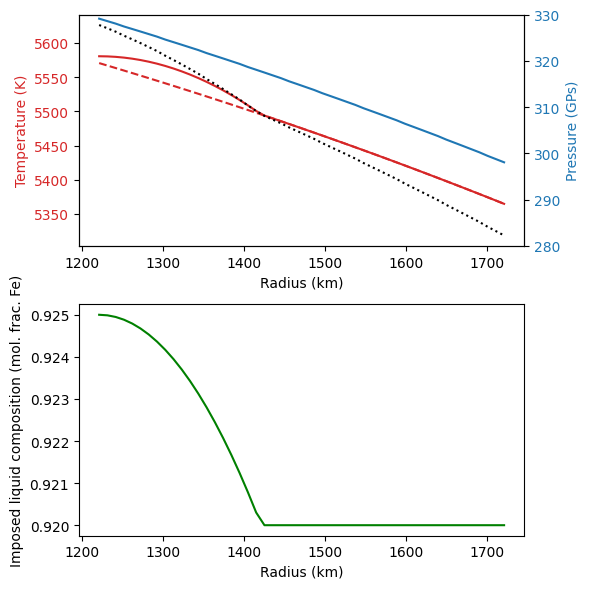

In [2]:
# This is where we set all the F-layer parameters. Quite slow (due to liquidus calc I think)

# F-layer setup
radius_inner_core = 1221.5e3
f_layer_thickness = 200.0e3
radius_top_flayer = radius_inner_core + f_layer_thickness # 200 km thick.
radius_cmb = 3480.0e3 # We only need this for setup.
gamma = 1.5
delta_t = 10.0
x_bulk = 0.92
x_icb = 0.925


# Discretisation points
number_of_points = 200
nucleation_radii = np.linspace(radius_inner_core, radius_top_flayer, number_of_points)
analysis_radii = np.linspace(radius_inner_core, radius_top_flayer, number_of_points)
knott_radii = np.linspace(radius_inner_core, radius_top_flayer, number_of_points)

# Check PREM works ... and print some interesting values
prem = earth_model.Prem()
print("Pressure at ICB:", prem.pressure(radius_inner_core/1000.0), "GPa")
print("Pressure at top of F-layer", prem.pressure(radius_top_flayer/1000.0), "GPa")
print("g at ICB:", prem.gravity(radius_inner_core/1000.0), "m/s**2")
print("g at top of F-layer", prem.gravity(radius_top_flayer/1000.0), "m/s**2")

# Generate the functions for temperautre,
# composition, pressure and gravity
tfunc, atfunc, flayer_temperature_function, t_func_creator, xfunc, pfunc, gfunc, x_func_creator = \
            layer_setup.setup_flayer_functions(radius_inner_core, radius_cmb, f_layer_thickness, 
                                                    gamma, delta_t, x_bulk, x_icb, knott_radii)

# Quadratic functions in the layer
tfunc = layer_setup.fit_quad_func_boundaries(
            radius_inner_core, radius_top_flayer, atfunc(radius_inner_core)+delta_t, 
            atfunc(radius_top_flayer))
xfunc = layer_setup.fit_quad_func_boundaries(
            radius_inner_core, radius_top_flayer, x_icb, x_bulk)


# Stitch the results back together
@np.vectorize
def full_temperature_function(r):
    if r < radius_top_flayer:
        return tfunc(r) 
    else:
        return atfunc(r)
        
@np.vectorize
def full_composition_function(r):
    if r < radius_top_flayer:
        return xfunc(r) 
    else:
        return x_bulk 


print("Temberature at top of F-layer is", full_temperature_function(radius_top_flayer), "K")
print("Temberature at ICB is", full_temperature_function(radius_inner_core), "K")

# Check the layer is stratified
Nbv, N2, liquid_density_excess = layer_setup.estimate_brunt_vaisala_frequency(
        radius_top_flayer, radius_inner_core, full_temperature_function, atfunc,
        full_composition_function, gfunc, pfunc)

print("Brunt Vaisala frequency is", Nbv, "Hz")

# Interpolate onto radius for plotting
rs = np.linspace(radius_inner_core, radius_inner_core+500.0E3)
ts = full_temperature_function(rs)
ats = atfunc(rs)
ps = pfunc(rs)
xs = full_composition_function(rs)
# Find the P-X dependent liquidus (storing the temperature at each point)
tl = feot.find_liquidus(xs, ps)


# Plot the F-layer setup alongside the liquidus
fig, ax = plt.subplots(figsize=(6,6), tight_layout=True, nrows=2)

color = 'tab:red'
ax[0].set_xlabel('Radius (km)')
ax[0].set_ylabel('Temperature (K)', color=color)
ax[0].plot(rs/1000.0, ts, color=color)
ax[0].plot(rs/1000.0, ats, color=color, ls='--')
ax[0].plot(rs/1000.0, tl, color='k', ls=':')

ax[0].tick_params(axis='y', labelcolor=color)
#ax1.set_ylim([5900, 6200])

ax2 = ax[0].twinx()  

color = 'tab:blue'
ax2.set_ylabel('Pressure (GPs)', color=color)  
ax2.plot(rs/1000.0, ps, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([280, 330])

ax[1].set_xlabel('Radius (km)')
ax[1].set_ylabel('Imposed liquid composition (mol. frac. Fe)')
ax[1].plot(rs/1000.0, xs, color='g')

fig.tight_layout()  
plt.show()

## Equilibrium calculation

For this temperature, pressure and bulk composition, calculate the equilbrium
volume fraction solid (and residual liquid composition) assuming phase equilibrium.
This makes use of the thermodymaic model and none of the growth, nucleation and falling
code.

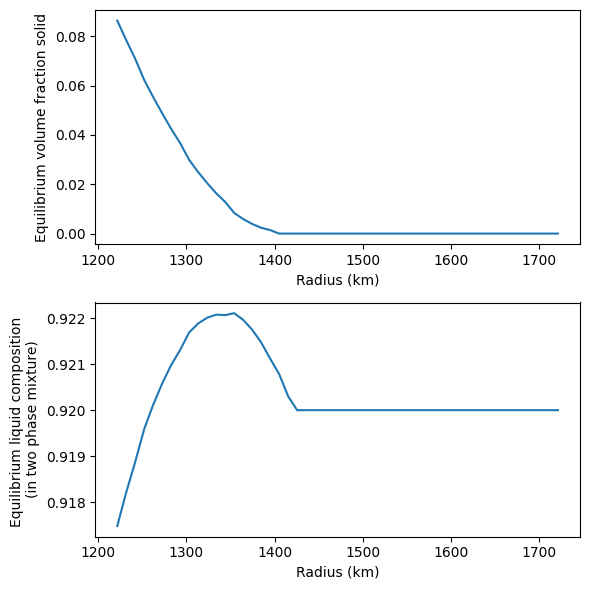

In [3]:
equilib_vol_frac = feot.volume_fraction_solid(xs, ps, ts)
x_lq, phi_fe, phi_lq, phi_feo, phi_solid = feot.phase_relations_molar(xs, ps, ts)

fig, ax = plt.subplots(nrows=2, figsize=(6,6), tight_layout=True)
ax[0].plot(rs/1000.0, equilib_vol_frac)
ax[0].set_ylabel('Equilibrium volume fraction solid')
ax[0].set_xlabel('Radius (km)')
ax[1].plot(rs/1000.0, x_lq)
ax[1].set_ylabel('Equilibrium liquid composition \n(in two phase mixture)')
ax[1].set_xlabel('Radius (km)')
plt.show()

## Run the non-equilibrium model

We need to add a bunch of parameters to run the non-equilibrium model in order to
include nucleation, growth and falling. Most of the code is inside `flayer`.

The first cell sets up and runs the calculation. Further cells plot different 
aspects of the results.

In [4]:
# IVP defaults
start_time = 0 # s
max_time = 1.0E20 # s

# Physical properties
initial_particle_size = 1.0E-9 # initial radius, m - should be critical radius for nucleation
k0 = 150.0 # growth rate prefactor, m/s
dl = 1.0E-9 # diffusion
mu = 1.0e-6 # kinematic viscosity
surface_energy = 1.08 # J/m^2
wetting_angle = 5.0
hetrogeneous_radius = 10.0E-10
i0 = 1.0E-10 # s^-1 m^-3 - other estimates include 0.71E-48...
k = 100 # W/m/K thermal diffusivity (not used) 

# Run all the IVPs and store results...
solutions, particle_densities, growth_rate, solid_vf, \
    particle_radii, partial_particle_densities, crit_nuc_radii, \
    nucleation_rates, _, _, total_latent_heat, total_o_rate, \
    solid_excess_density = flayer.evaluate_flayer(
    tfunc, xfunc, pfunc, gfunc, 0.0, 1.0E20, k0, dl, k, mu, i0, surface_energy, 
    wetting_angle, hetrogeneous_radius, nucleation_radii, analysis_radii, radius_inner_core, 
    radius_top_flayer, Nbv, verbose=False, silent=True, diffusion_problem=False)

print("Maximum nucleation rate:", np.nanmax(nucleation_rates), "m^-1 s^-1")

# Exract further information from the solutions
calculated_seperation, growth_rate, vf_ratio = flayer.analyse_flayer(solutions, nucleation_radii, analysis_radii, nucleation_rates, radius_inner_core,
                   particle_densities, growth_rate, solid_vf, 
                   particle_radii, partial_particle_densities, tfunc, xfunc, pfunc, verbose=False)

/Users/andreww/Code/slurry/flayer.py:499: RuntimeWarning: invalid value encountered in divide
  mean_particle_velocities[i] = np.mean((partial_densities * partial_velocities) /


Maximum nucleation rate: 7.023604013412353e-11 m^-1 s^-1


/Users/andreww/Code/slurry/flayer.py:261: RuntimeWarning: invalid value encountered in divide
  vf_ratio =  solid_vf / feot.volume_fraction_solid(xfunc(analysis_radii),


/var/folders/j_/przs7cfj1b7czhv250v8t_440000gn/T/ipykernel_44617/1646221193.py:15: RuntimeWarning: invalid value encountered in divide
  solid_vf[1:-1] / feot.volume_fraction_solid(xfunc(analysis_radii[1:-1]),


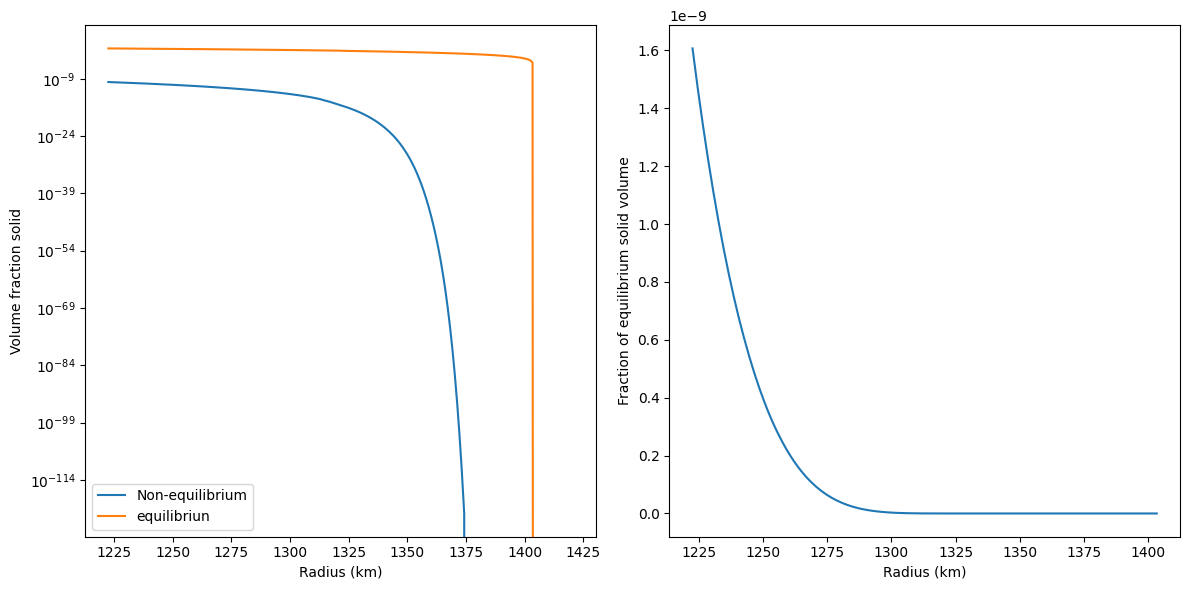

In [5]:
fig, axs = plt.subplots(ncols=2, figsize=(12,6), tight_layout=True)
ax = axs[0]
ax.plot(analysis_radii[1:-1]/1000.0, solid_vf[1:-1], label='Non-equilibrium')

ax.plot(analysis_radii[1:-1]/1000.0, feot.volume_fraction_solid(xfunc(analysis_radii[1:-1]), 
                                                                pfunc(analysis_radii[1:-1]), 
                                                                tfunc(analysis_radii[1:-1])), label='equilibriun')
ax.set_yscale("log", nonpositive='clip')
ax.set_ylabel('Volume fraction solid')
ax.set_xlabel('Radius (km)')
ax.legend()

ax = axs[1]
ax.plot(analysis_radii[1:-1]/1000.0, 
        solid_vf[1:-1] / feot.volume_fraction_solid(xfunc(analysis_radii[1:-1]), 
                                                                pfunc(analysis_radii[1:-1]), 
                                                                tfunc(analysis_radii[1:-1])))
ax.set_ylabel('Fraction of equilibrium solid volume')
ax.set_xlabel('Radius (km)')

plt.show()

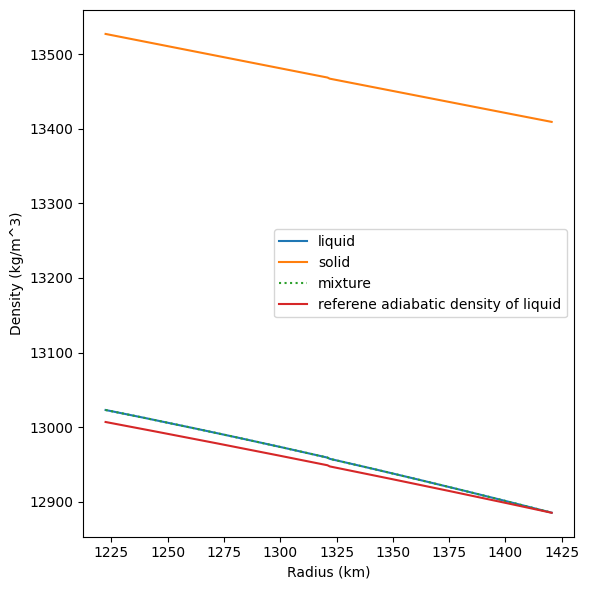

In [6]:
liquid_density, solid_mixture_density, fe_liquid_density, fe_hpc_density, \
           feo_liquid_density, feo_solid_density = feot.densities(xfunc(analysis_radii[1:-1]),
                                                                  pfunc(analysis_radii[1:-1]), 
                                                                  tfunc(analysis_radii[1:-1]))

ad_liquid_density, _, _, _, _, _ = feot.densities(xfunc(radius_top_flayer) * np.ones_like(analysis_radii[1:-1]),
                                                  pfunc(analysis_radii[1:-1]), 
                                                  atfunc(analysis_radii[1:-1]))

fig, axs = plt.subplots( figsize=(6,6), tight_layout=True)

ax = axs
ax.plot(analysis_radii[1:-1]/1000.0, liquid_density, label='liquid')
ax.plot(analysis_radii[1:-1]/1000.0, fe_hpc_density, label='solid')
ax.plot(analysis_radii[1:-1]/1000.0, fe_hpc_density*solid_vf[1:-1] + liquid_density*(1.0-solid_vf[1:-1]),
        label='mixture', ls=':')
ax.plot(analysis_radii[1:-1]/1000.0, ad_liquid_density,
        label='referene adiabatic density of liquid', ls='-')
ax.set_xlabel('Radius (km)')
ax.set_ylabel('Density (kg/m^3)')
ax.legend()

plt.show()

Particle radii between 0.0229 and 1.1e-05 m


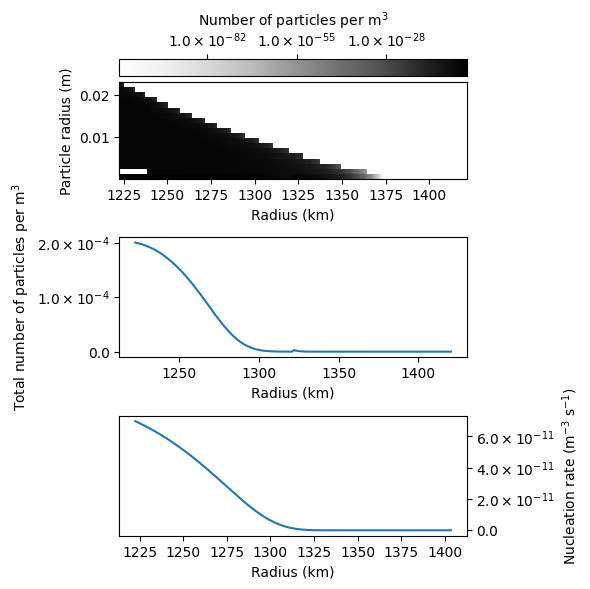

In [7]:
max_particle_radius = particle_radii[particle_radii > 0.0].max()
min_particle_radius = particle_radii[particle_radii > 0.0].min()
print("Particle radii between {:.3g} and {:.3g} m".format(max_particle_radius, min_particle_radius))

particle_size_distributions = []
edges = None
binsin = np.linspace(min_particle_radius, max_particle_radius, 20)

for i, r in enumerate(analysis_radii):
    csd, edg = np.histogram(particle_radii[i,:], 
                            weights=partial_particle_densities[i,:],
                            range=(min_particle_radius, max_particle_radius),
                            bins=binsin)
    if edges is None:
        edges = edg
    else:
        assert np.array_equal(edges, edg)
    
    particle_size_distributions.append(csd)

csd = np.array(particle_size_distributions)


def sciformat(x, pos=None):
    if x == 0:
        return "0.0"
    scistr = "{:E}".format(x)
    vals = scistr.split('E')
    fmttick = "${:.1f}".format(float(vals[0])) + r"\times 10^{" + "{}".format(int(vals[1])) + "}$"
    return fmttick

fig, axs = plt.subplots(nrows=3, figsize=(6,6))
fig.subplots_adjust(hspace=0, wspace=0.1)

ax = axs[0]
im = ax.imshow(csd[1:,:].T, aspect='auto', interpolation='none', 
              cmap=plt.get_cmap('Greys'), origin='lower', 
              extent=[analysis_radii[1]/1000.0, analysis_radii[-1]/1000.0,
                      edges[0], edges[-1]], norm=colors.LogNorm())
ax.set_ylabel('Particle radius (m)')
ax.set_xlabel('Radius (km)')
#ax.set_yscale('log')

cb = plt.colorbar(im, ax=ax, location='top')
cb.set_label('Number of particles per m$^{3}$')
cb.ax.xaxis.set_major_formatter(sciformat)
cb.ax.xaxis.set_major_locator(ticker.LogLocator(numticks=4))

ax = axs[1]
ax.plot(analysis_radii[1:-1]/1000.0, csd[1:-1,:].sum(axis=1))

ax.set_xlabel('Radius (km)')
ax.set_ylabel('Total number of particles per m$^3$')
ax.yaxis.set_major_formatter(sciformat)

ax = axs[2]
ax.plot(analysis_radii[1:-1]/1000.0,nucleation_rates[1:-1])
ax.yaxis.set_major_formatter(sciformat)
ax.set_xlabel('Radius (km)')
ax.set_ylabel('Nucleation rate (m$^{-3}$ s$^{-1}$)')
ax.yaxis.set_ticks_position('right')
ax.yaxis.set_label_position("right")
#ax.set_yscale('log')

fig.tight_layout()
plt.show()

## Plot details of individual particles

We can look at individual solutions to the IVPs (labeled `s`
below) and extract dignostic information (some of which is recalculated
from the stored data).

Particle formed at 1226.5 km
Initial radius was 1.0 nm
Falling time was 1.38 days
Final radius was 0.58 cm


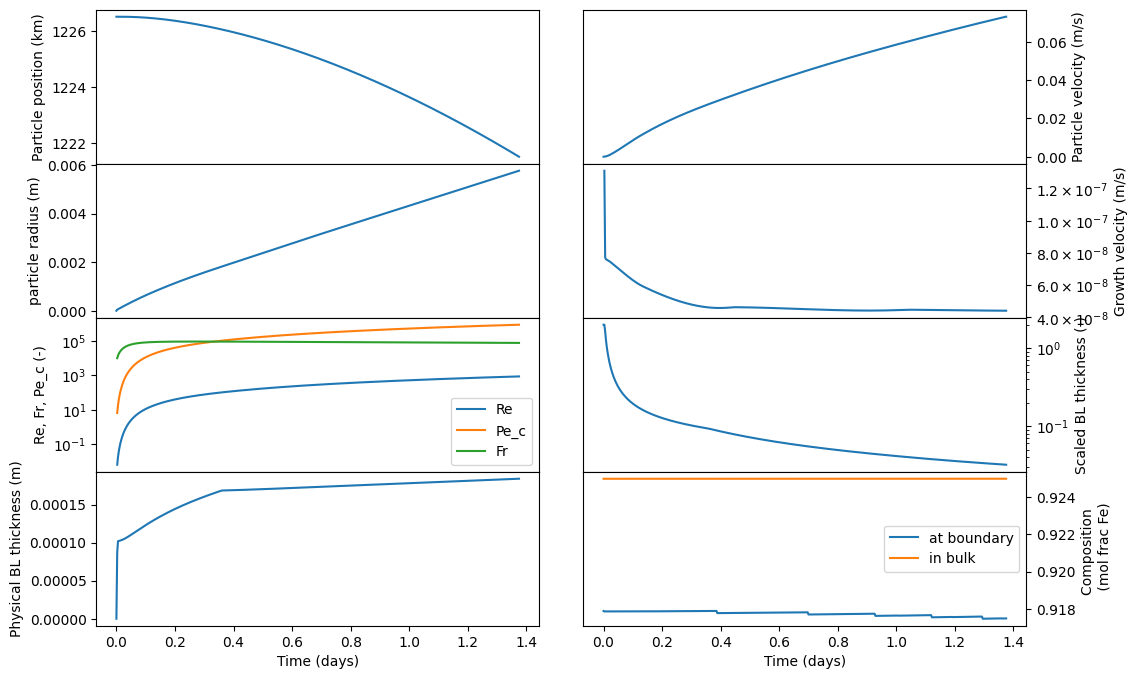

Particle formed at 1271.8 km
Initial radius was 1.0 nm
Falling time was 6.59 days
Final radius was 1.73 cm


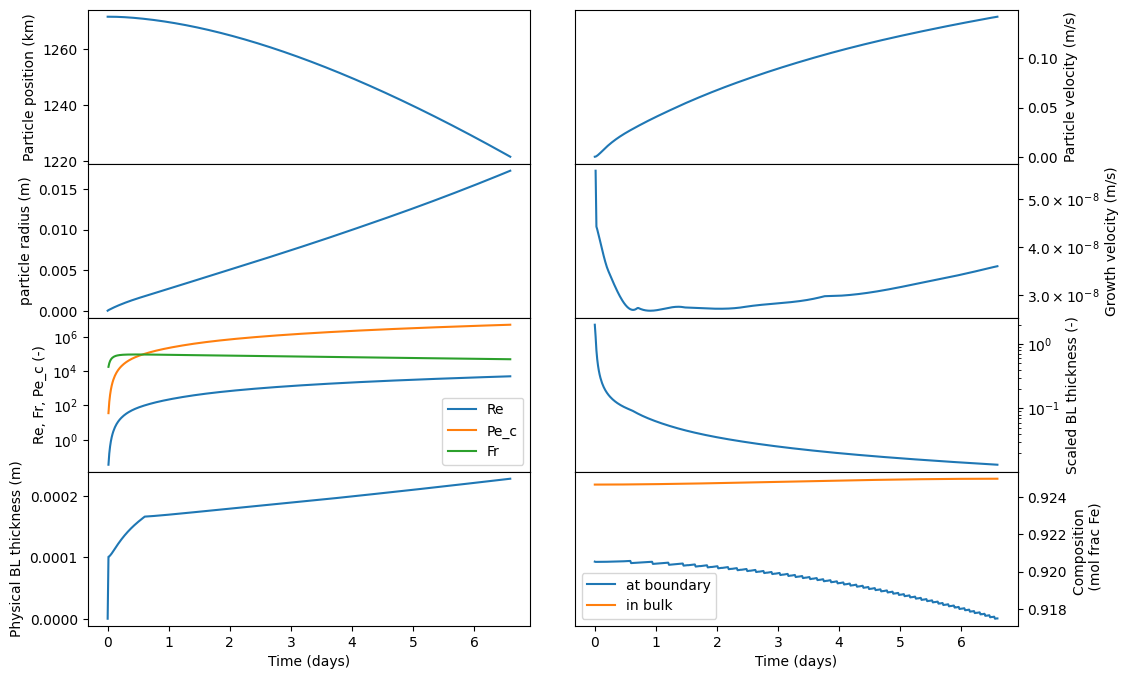

Particle formed at 1322.0 km
Initial radius was 1.0 nm
Falling time was 12.92 days
Final radius was 2.16 cm


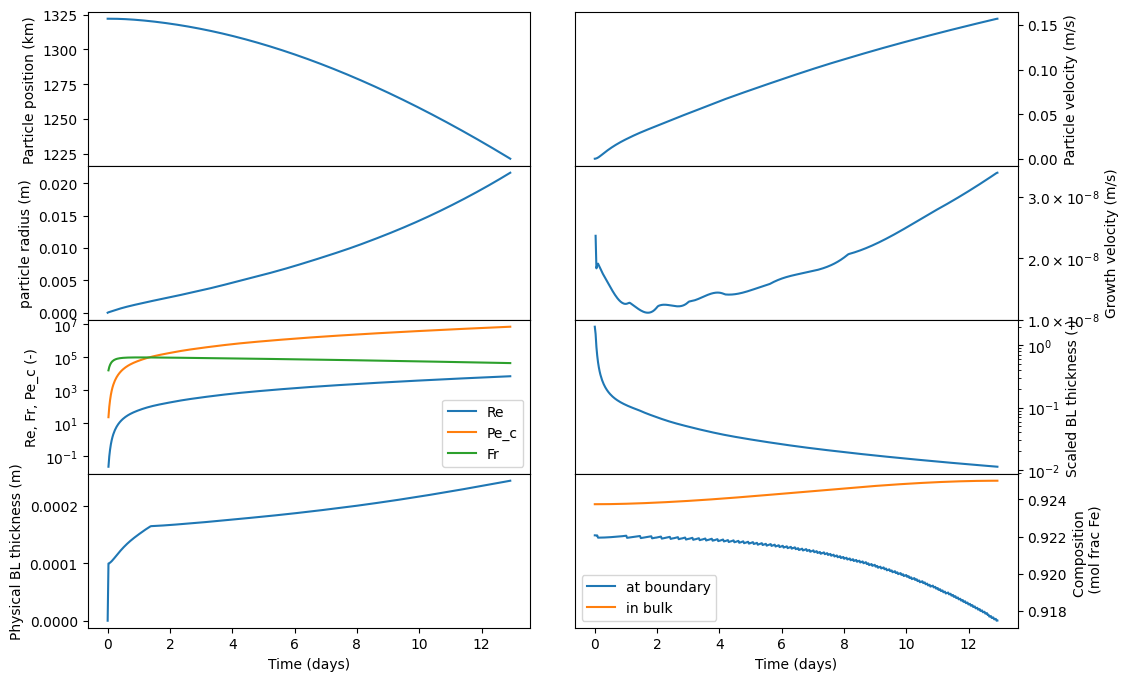

Particle formed at 1372.3 km
Initial radius was 1.0 nm
Falling time was 25.02 days
Final radius was 2.29 cm


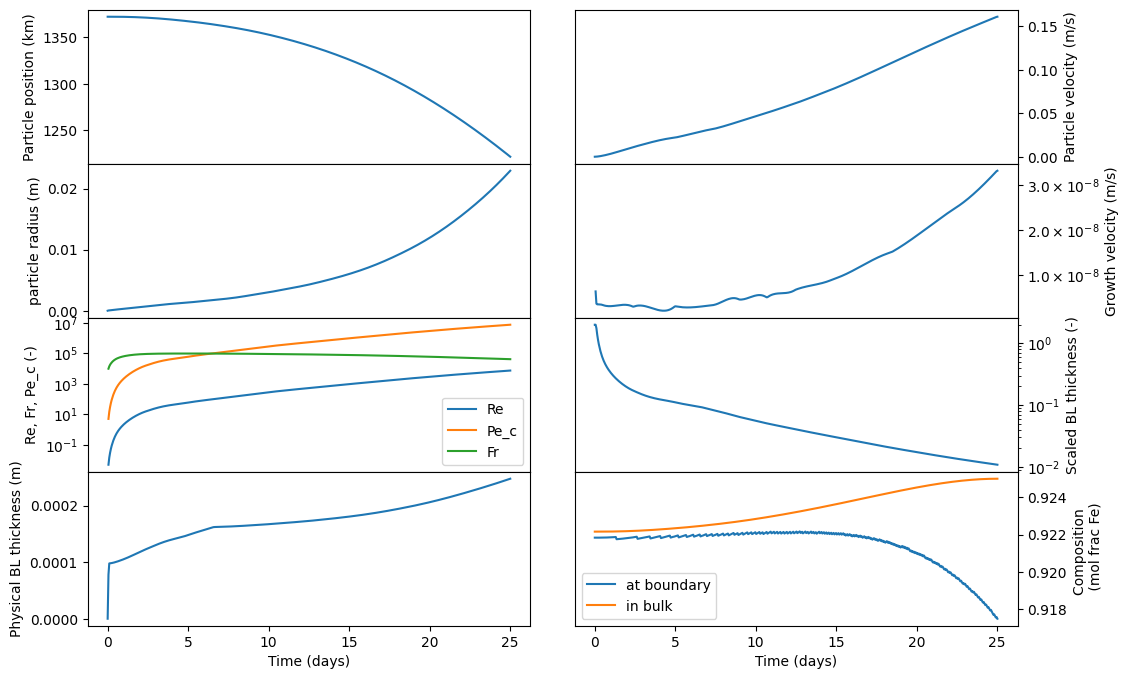

No particle formed for solution number 195


In [8]:
# Plot details of selected solutions (we have 200 in this case, but some
# near the top may not exist)

for s in [5, 50, 100, 150, 195]:
    if solutions[s] is not None:
        initial_position = solutions[s].y[1][0] / 1000.0
        initial_radius = solutions[s].y[0][0] * 1.0E9
        final_radius = solutions[s].y[0][-1] * 100.0
        falling_time = solutions[s].sol.ts[-1] /(60 * 60 * 24)
        print(f"Particle formed at {initial_position:.1f} km")
        print(f"Initial radius was {initial_radius:.1f} nm")
        print(f"Falling time was {falling_time:.2f} days")
        print(f"Final radius was {final_radius:.2f} cm")
        particle_evolution.plot_particle_evolution_time(solutions[s], xfunc, tfunc, pfunc, dl, k0, gfunc, mu, 
                                     Nbv, include_solution_points=False)
    else:
        print(f"No particle formed for solution number {s}")